In [ ]:
!pip install -q gensim hmmlearn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Download NLTK data (tokenizer, stopwords, POS tagger, lemmatizer)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("All imports ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 10.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All imports ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path if you put the CSV somewhere else in Drive
DATA_PATH = '/content/drive/My Drive/SarcasmProject/data/train-balanced-sarcasm.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
df.head()

Mounted at /content/drive
Dataset shape: (1010826, 10)

Columns: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']

Label distribution:
label
0    505413
1    505413
Name: count, dtype: int64


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...


In [ ]:
df = df[['comment', 'label']].copy()
df.dropna(subset=['comment'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Clean dataset: {len(df)} rows")
print(f"Sarcastic: {df['label'].sum()}, Genuine: {(df['label'] == 0).sum()}")


Clean dataset: 1010771 rows
Sarcastic: 505368, Genuine: 505403


In [ ]:
def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)               # keep only letters & spaces
    text = re.sub(r'\s+', ' ', text).strip()           # collapse multiple spaces
    return text


df['clean'] = df['comment'].apply(clean_text)
print("=== Before vs After Cleaning ===")
for i in range(5):
    print(f"\nOriginal : {df['comment'].iloc[i]}")
    print(f"Cleaned  : {df['clean'].iloc[i]}")

=== Before vs After Cleaning ===

Original : NC and NH.
Cleaned  : nc and nh

Original : You do know west teams play against west teams more than east teams right?
Cleaned  : you do know west teams play against west teams more than east teams right

Original : They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1
Cleaned  : they were underdogs earlier today but since gronks announcement this afternoon the vegas line has moved to patriots

Original : This meme isn't funny none of the "new york nigga" ones are.
Cleaned  : this meme isnt funny none of the new york nigga ones are

Original : I could use one of those tools.
Cleaned  : i could use one of those tools


In [ ]:
df['tokens'] = df['clean'].apply(word_tokenize)

# Show example
print("Example tokens:")
for i in range(3):
    print(f"  {df['tokens'].iloc[i][:10]}...")

total_tokens = df['tokens'].apply(len).sum()
print(f"\nTotal tokens in corpus: {total_tokens:,}")

Example tokens:
  ['nc', 'and', 'nh']...
  ['you', 'do', 'know', 'west', 'teams', 'play', 'against', 'west', 'teams', 'more']...
  ['they', 'were', 'underdogs', 'earlier', 'today', 'but', 'since', 'gronks', 'announcement', 'this']...

Total tokens in corpus: 10,447,507


In [ ]:
stop_words = set(stopwords.words('english'))
print(f"Number of stopwords: {len(stop_words)}")
print(f"Examples: {list(stop_words)[:15]}")

df['tokens_clean'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

# Show effect
print("\n=== Before vs After Stopword Removal ===")
for i in range(3):
    print(f"\nWith stopwords   : {df['tokens'].iloc[i][:10]}")
    print(f"Without stopwords: {df['tokens_clean'].iloc[i][:10]}")



Number of stopwords: 198
Examples: ['hers', 'is', "mustn't", 'been', 'once', 'against', 'did', 'under', "she'll", 'same', 'we', 'his', 'o', 'a', 'more']

=== Before vs After Stopword Removal ===

With stopwords   : ['nc', 'and', 'nh']
Without stopwords: ['nc', 'nh']

With stopwords   : ['you', 'do', 'know', 'west', 'teams', 'play', 'against', 'west', 'teams', 'more']
Without stopwords: ['know', 'west', 'teams', 'play', 'west', 'teams', 'east', 'teams', 'right']

With stopwords   : ['they', 'were', 'underdogs', 'earlier', 'today', 'but', 'since', 'gronks', 'announcement', 'this']
Without stopwords: ['underdogs', 'earlier', 'today', 'since', 'gronks', 'announcement', 'afternoon', 'vegas', 'line', 'moved']


In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Apply stemming
df['stemmed'] = df['tokens_clean'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

# Apply lemmatization
df['lemmatized'] = df['tokens_clean'].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

# Side-by-side comparison
print("=== Stemming vs Lemmatization ===")
print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("-" * 45)
sample_words = ['running', 'studies', 'better', 'easily', 'fairly',
                'caring', 'obviously', 'sarcastically', 'happiness', 'wolves']
for w in sample_words:
    print(f"{w:<15} {stemmer.stem(w):<15} {lemmatizer.lemmatize(w):<15}")


=== Stemming vs Lemmatization ===
Word            Stemmed         Lemmatized     
---------------------------------------------
running         run             running        
studies         studi           study          
better          better          better         
easily          easili          easily         
fairly          fairli          fairly         
caring          care            caring         
obviously       obvious         obviously      
sarcastically   sarcast         sarcastically  
happiness       happi           happiness      
wolves          wolv            wolf           


Vocabulary size: 181,520
Total words: 5,760,639


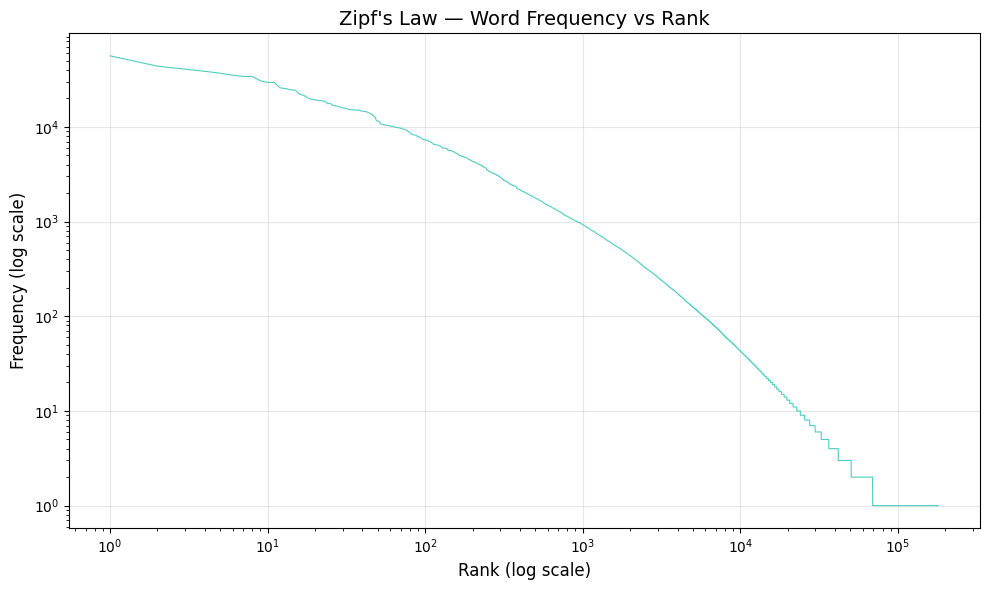

✓ Saved: zipf_law.png
If this is roughly a straight line, Zipf's Law holds. ✓


In [ ]:
all_words = [w for tokens in df['lemmatized'] for w in tokens]
word_freq = Counter(all_words)
print(f"Vocabulary size: {len(word_freq):,}")
print(f"Total words: {len(all_words):,}")

# Sort by frequency (most common first)
sorted_freq = sorted(word_freq.values(), reverse=True)
ranks = range(1, len(sorted_freq) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_freq, linewidth=0.8, color='#4ECDC4')
plt.xlabel('Rank (log scale)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title("Zipf's Law — Word Frequency vs Rank", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/SarcasmProject/outputs/zipf_law.png', dpi=150)
plt.show()
print("✓ Saved: zipf_law.png")
print("If this is roughly a straight line, Zipf's Law holds. ✓")


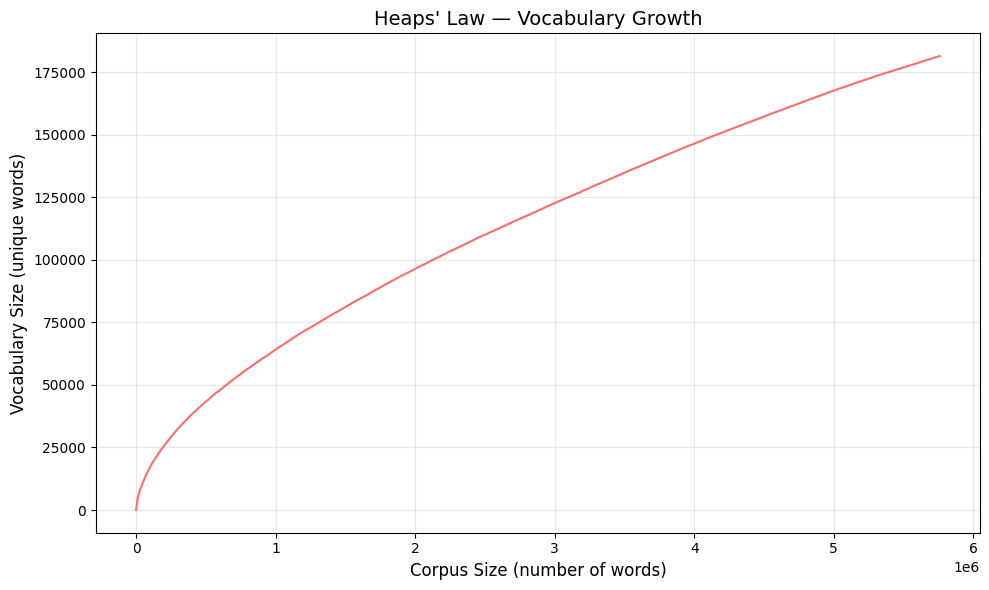

✓ Saved: heaps_law.png
The curve should flatten — vocabulary growth slows as corpus grows. ✓


In [ ]:
sample_points = range(0, len(all_words), 10000)
vocab_growth = []
seen = set()

word_list = all_words  # already flat list
idx = 0
for target in sample_points:
    while idx <= target and idx < len(word_list):
        seen.add(word_list[idx])
        idx += 1
    vocab_growth.append((target + 1, len(seen)))

corpus_sizes, vocab_sizes = zip(*vocab_growth)

plt.figure(figsize=(10, 6))
plt.plot(corpus_sizes, vocab_sizes, linewidth=1.5, color='#FF6B6B')
plt.xlabel('Corpus Size (number of words)', fontsize=12)
plt.ylabel('Vocabulary Size (unique words)', fontsize=12)
plt.title("Heaps' Law — Vocabulary Growth", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/SarcasmProject/outputs/heaps_law.png', dpi=150)
plt.show()
print("✓ Saved: heaps_law.png")
print("The curve should flatten — vocabulary growth slows as corpus grows. ✓")


In [ ]:
# Join lemmatized tokens back into a string for easy loading later
df['processed_text'] = df['lemmatized'].apply(lambda tokens: ' '.join(tokens))

# Save only what we need going forward
output_df = df[['comment', 'processed_text', 'label']].copy()

save_path = '/content/drive/My Drive/SarcasmProject/data/processed_data.csv'
output_df.to_csv(save_path, index=False)
print(f"✓ Saved processed data: {save_path}")
print(f"  Rows: {len(output_df):,}")
print(f"  Columns: {list(output_df.columns)}")

# Quick stats
print(f"\n=== Final Stats ===")
print(f"Total comments: {len(output_df):,}")
print(f"Sarcastic: {output_df['label'].sum():,}")
print(f"Genuine: {(output_df['label'] == 0).sum():,}")
print(f"Avg tokens per comment: {df['lemmatized'].apply(len).mean():.1f}")



✓ Saved processed data: /content/drive/My Drive/SarcasmProject/data/processed_data.csv
  Rows: 1,010,771
  Columns: ['comment', 'processed_text', 'label']

=== Final Stats ===
Total comments: 1,010,771
Sarcastic: 505,368
Genuine: 505,403
Avg tokens per comment: 5.7
